In [ ]:
# !pip -q install datasets torchaudio torch torchvision scikit-learn transformers accelerate --upgrade

In [ ]:
# !pip install -U torchaudio datasets transformers
# !pip install soundfile librosa

In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchaudio
import torchaudio.transforms as T
from datasets import load_dataset, Audio
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
from transformers import AutoProcessor, AutoModelForAudioClassification, TrainingArguments, Trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
SR = 16000


Device: cuda


# Лабораторная работа №2: Классификация аудио

In [2]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_SILENT"] = "true"

!export WANDB_DISABLED=true

import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*wandb.*")

In [3]:
!pip install --upgrade torchcodec

In [4]:
# import os
# os.environ["HF_AUDIO_DECODER"] = "torchaudio"

import torchcodec
print(torchcodec.__version__)
ds = load_dataset("danavery/urbansound8K")
# ds = ds.cast_column("audio", Audio(sampling_rate=SR,decode=False))
ds = ds.cast_column("audio", Audio(sampling_rate=SR))

def by_fold(d, folds): return d.filter(lambda ex: ex["fold"] in folds)

train_raw = by_fold(ds["train"], list(range(1,9)))   # 1..8
valid_raw = by_fold(ds["train"], [9])                # 9
test_raw  = by_fold(ds["train"], [10])               # 10
# train_raw = train_raw.cast_column("audio", Audio(sampling_rate=SR, decode=True))
# valid_raw = valid_raw.cast_column("audio", Audio(sampling_rate=SR, decode=True))
# test_raw = test_raw.cast_column("audio", Audio(sampling_rate=SR, decode=True))

labels = sorted(list(set(train_raw["class"])))
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
label_col = "class"

len(train_raw), len(valid_raw), len(test_raw), len(labels)


0.7.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Filter:   0%|          | 0/8732 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8732 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8732 [00:00<?, ? examples/s]

(7079, 816, 837, 10)

In [5]:
N_MELS, N_FFT, HOP = 64, 1024, 256
FMIN, FMAX = 20.0, SR/2
mel = T.MelSpectrogram(sample_rate=SR, n_fft=N_FFT, hop_length=HOP,
                       n_mels=N_MELS, f_min=FMIN, f_max=FMAX, power=2.0)
to_db = T.AmplitudeToDB(top_db=80)

def logmel_stats(ex):
    wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        S = to_db(mel(wav)).squeeze(0).numpy().astype("float32")  # (M,T)
    m, s = S.mean(), S.std() + 1e-6
    S = (S - m) / s
    feat = np.concatenate([S.mean(1), S.std(1)]).astype("float32")
    return {"feat": feat, "y": label2id[ex[label_col]]}

def to_xy(split): # преобразование датасета в фичи и метки для классификатора
    a = split.map(logmel_stats, remove_columns=split.column_names)
    return np.stack(a["feat"]), np.array(a["y"])

X_tr, y_tr = to_xy(train_raw)
X_va, y_va = to_xy(valid_raw)
X_te, y_te = to_xy(test_raw)

# пайплайн из StandardScaler(): стандартизация данных (mean=0, std=1)
# и LinearSVC(): линейный метод опорных векторов для классификации
clf = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC())])
clf.fit(X_tr, y_tr)
print("LinearSVC  VAL acc:", accuracy_score(y_va, clf.predict(X_va)))
print("LinearSVC  TEST acc:", accuracy_score(y_te, clf.predict(X_te)))


Map:   0%|          | 0/7079 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/837 [00:00<?, ? examples/s]

LinearSVC  VAL acc: 0.5551470588235294
LinearSVC  TEST acc: 0.5077658303464755


In [6]:
class RawWaveDS(Dataset):
    def __init__(self, split): self.s = split
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        ex = self.s[i]
        return torch.tensor(ex["audio"]["array"], dtype=torch.float32), label2id[ex[label_col]]

# дополняет более короткие аудио нулями
def pad_collate(batch):
    waves, ys = zip(*batch)
    L = max(w.shape[0] for w in waves)
    X = torch.zeros(len(waves), L)
    for i,w in enumerate(waves): X[i,:w.shape[0]] = w
    return X, torch.tensor(ys, dtype=torch.long)

train_loader = DataLoader(RawWaveDS(train_raw), batch_size=32, shuffle=True,  num_workers=0, collate_fn=pad_collate)
val_loader   = DataLoader(RawWaveDS(valid_raw), batch_size=32, shuffle=False, num_workers=0, collate_fn=pad_collate)
test_loader  = DataLoader(RawWaveDS(test_raw),  batch_size=32, shuffle=False, num_workers=0, collate_fn=pad_collate)

mel_gpu = T.MelSpectrogram(sample_rate=SR, n_fft=N_FFT, hop_length=HOP,
                           n_mels=N_MELS, f_min=FMIN, f_max=FMAX, power=2.0).to(device)
to_db_gpu = T.AmplitudeToDB(top_db=80).to(device)
FIX_T = 128

def to_logmel_batch(xb_1d):
    S = to_db_gpu(mel_gpu(xb_1d))          # (B,M,Tm)
    m = S.mean(dim=(1,2), keepdim=True); s = S.std(dim=(1,2), keepdim=True).clamp_min(1e-6)
    S = (S - m)/s
    Tm = S.size(-1)
    if Tm < FIX_T: S = F.pad(S, (0, FIX_T-Tm))
    else: S = S[:, :, :FIX_T]
    return S.unsqueeze(1)                  # (B,1,M,FIX_T)

class VGGishAudio(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.h = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.h(self.f(x))


model = VGGishAudio(len(label2id)).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

def run_epoch(loader, train=True, tag=""):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for xb_wave, yb in tqdm(loader, desc=tag, leave=False):
        xb_wave, yb = xb_wave.to(device), yb.to(device)
        xb = to_logmel_batch(xb_wave)
        if train: opt.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits = model(xb); loss = crit(logits, yb)
            if train: loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0)
        pred = logits.argmax(1); correct += (pred==yb).sum().item(); total += xb.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

    accuracy = correct/total
    f1 = f1_score(all_targets, all_preds, average='macro')
    return loss_sum/total, accuracy, f1

epochs = 8
cnn_history = {
    "tr_loss": [], "tr_acc": [], "tr_f1": [],
    "va_loss": [], "va_acc": [], "va_f1": []
}

for ep in range(1, epochs):
    tr_l, tr_a, tr_f1 = run_epoch(train_loader, True,  f"train {ep}/{epochs}")
    va_l, va_a, va_f1 = run_epoch(val_loader,   False, f"valid {ep}/{epochs}")
    cnn_history["tr_loss"].append(tr_l)
    cnn_history["tr_acc"].append(tr_a)
    cnn_history["tr_f1"].append(tr_f1)
    cnn_history["va_loss"].append(va_l)
    cnn_history["va_acc"].append(va_a)
    cnn_history["va_f1"].append(va_f1)
    print(f"Ep {ep:02d}: train {tr_l:.4f}/{tr_a:.3f} | valid {va_l:.4f}/{va_a:.3f}")

# Тест
model.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for xb_wave, yb in tqdm(test_loader, desc="test", leave=False):
        logits = model(to_logmel_batch(xb_wave.to(device)))
        y_true += yb.numpy().tolist()
        y_pred += logits.argmax(1).cpu().numpy().tolist()
print("CNN TEST acc:", accuracy_score(y_true, y_pred))
print("CNN TEST f1:", f1_score(y_true, y_pred, average='macro'))


Ep 01: train 1.4430/0.482 | valid 1.3822/0.558


Ep 02: train 0.9649/0.669 | valid 2.2255/0.373


Ep 03: train 0.7772/0.742 | valid 1.1862/0.612


Ep 04: train 0.6399/0.793 | valid 1.1560/0.659


Ep 05: train 0.5533/0.822 | valid 1.9118/0.545


Ep 06: train 0.5137/0.833 | valid 1.3001/0.676


Ep 07: train 0.4525/0.853 | valid 2.1827/0.471


CNN TEST acc: 0.5304659498207885
CNN TEST f1: 0.5686431818402319


In [ ]:
# Ep 01: train 1.3818/0.514 | valid 2.1883/0.355
# Ep 02: train 0.9186/0.686 | valid 1.2626/0.562
# Ep 03: train 0.7368/0.754 | valid 1.1993/0.663
# Ep 04: train 0.6279/0.799 | valid 1.2835/0.672
# Ep 05: train 0.5515/0.820 | valid 1.1690/0.712
# Ep 06: train 0.4831/0.838 | valid 1.5422/0.632
# Ep 07: train 0.4339/0.860 | valid 0.9446/0.748

# CNN TEST acc: 0.6654719235364397
# CNN TEST f1: 0.6830814807134582

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_SILENT"] = "true"

!export WANDB_DISABLED=true

import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*wandb.*")

In [22]:
# Audio Spectrogram Transformer
# от архитектуры Vision Transformer, но адаптированная для спектрограмм
MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
processor = AutoProcessor.from_pretrained(MODEL_ID)
ast = AutoModelForAudioClassification.from_pretrained(
    MODEL_ID, num_labels=len(labels), label2id=label2id, id2label=id2label,
    ignore_mismatched_sizes=True
).to(device)
# Адаптация ее для 10 классов UrbanSound8K вместо исходных 527 классов AudioSet
# Processor подготавливает аудио: преобразует в спектрограмму, нормализует, разбивает на патчи

#переформатирование данных
def map_raw(ex):
    return {
        "wave": np.asarray(ex["audio"]["array"], dtype="float32"),
        "labels": label2id[ex[label_col]],
    }

tr_ast = train_raw.map(map_raw, remove_columns=train_raw.column_names, load_from_cache_file=False)
va_ast = valid_raw.map(map_raw, remove_columns=valid_raw.column_names, load_from_cache_file=False)
te_ast = test_raw .map(map_raw, remove_columns=test_raw .column_names, load_from_cache_file=False)



def collate_proc(batch):
    def extract_wave(b):
        if "wave" in b:
            return b["wave"]
        if "audio" in b and isinstance(b["audio"], dict) and "array" in b["audio"]:
            return b["audio"]["array"]
        if "input_values" in b:
            return b["input_values"]
        raise KeyError(f"Expected one of keys ['wave','audio','input_values'], got {list(b.keys())}")

    waves  = [extract_wave(b) for b in batch]
    labels = [b["labels"] if "labels" in b else b["label"] for b in batch]

    inputs = processor(waves, sampling_rate=SR, return_tensors="pt",
                       padding=True, truncation=True)
    inputs["labels"] = torch.tensor(labels, dtype=torch.long)
    return inputs



def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, -1)
    return {"accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro"))}

args = TrainingArguments(
    output_dir="ast_us8k_ft",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_steps=500,
    logging_steps=200,
    fp16=(device.type=="cuda"),
    overwrite_output_dir=True,
    do_train=True,
    do_eval=True,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=ast,
    args=args,
    train_dataset=tr_ast,
    eval_dataset=va_ast,
    data_collator=collate_proc,
    processing_class=processor,
    compute_metrics=compute_metrics,
)

trainer.train()
ast_val_results = trainer.evaluate(va_ast)
ast_test_results = trainer.evaluate(te_ast)


ast_val_acc = ast_val_results['eval_accuracy']
ast_val_f1 = ast_val_results['eval_f1_macro']
ast_test_acc = ast_test_results['eval_accuracy']
ast_test_f1 = ast_test_results['eval_f1_macro']
print("AST VALID: ")
print("acc = ", ast_val_acc)
print("f1 = ", ast_val_f1)
print("AST TEST:")
print("acc = ", ast_test_acc)
print("f1 = ", ast_test_f1)


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/837 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.199800,0.689062,0.867647,0.878908
2,0.053400,0.875045,0.875000,0.886539


AST VALID: 
acc =  0.875
f1 =  0.8865391187105839
AST TEST:
acc =  0.899641577060932
f1 =  0.907837633524123


## Задание 1. Таблица сравнения и графики обучения (CNN vs AST)


In [ ]:
# AST VALID:
# acc =  0.8762254901960784
# f1 =  0.8870378201004424
# AST TEST:
# acc =  0.8888888888888888
# f1 =  0.9001650419053095

# Epoch	Training Loss	Validation Loss	Accuracy	F1 Macro
# 1	0.199400	0.757313	0.855392	0.863596
# 2	0.037100	0.733385	0.876225	0.887038


In [ ]:
# TODO(1.1): Таблица сравнения (VAL/TEST) для CNN и AST
# Подставьте ваши значения метрик. Если их нет — посчитайте/извлеките выше.
# Требуемые поля: cnn_val_acc, cnn_val_f1, cnn_test_acc, cnn_test_f1
#                 ast_val_acc, ast_val_f1, ast_test_acc, ast_test_f1

import pandas as pd

# --- Пример: замените None на ваши переменные/числа ---
cnn_val_acc  = 0.7377450980392157  # TODO
cnn_val_f1   = 0.73775873632934  # TODO
cnn_test_acc = 0.6654719235364397  # TODO
cnn_test_f1  = 0.6830814807134582  # TODO

ast_val_acc  = 0.8762254901960784  # TODO
ast_val_f1   = 0.8870378201004424  # TODO
ast_test_acc = 0.8888888888888888  # TODO
ast_test_f1  = 0.9001650419053095  # TODO

# specaugment(xb,time_mask=15,freq_mask=6,n_time_masks=2,n_freq_masks=1)
# aug_cnn_val_acc  = 0.6727941176470589
# aug_cnn_val_f1   = 0.677991229655896
# aug_cnn_test_acc = 0.6523297491039427
# aug_cnn_test_f1  = 0.643502338756303

# specaugment(xb, time_mask=8,freq_mask=3, n_time_masks=2, n_freq_masks=1)
aug_cnn_val_acc  = 0.7610294117647058
aug_cnn_val_f1   = 0.7665414967524801
aug_cnn_test_acc = 0.7933094384707288
aug_cnn_test_f1  = 0.8067319461814313


results = pd.DataFrame([
    ["CNN (VGG)", cnn_val_acc, cnn_val_f1, cnn_test_acc, cnn_test_f1],
    ["CNN Aug",    aug_cnn_val_acc, aug_cnn_val_f1, aug_cnn_test_acc, aug_cnn_test_f1],
    ["AST FT",    ast_val_acc, ast_val_f1, ast_test_acc, ast_test_f1],
], columns=["Model", "VAL acc", "VAL f1_macro", "TEST acc", "TEST f1_macro"])

results


,Model,VAL acc,VAL f1_macro,TEST acc,TEST f1_macro
0,CNN (VGG),0.737745,0.737759,0.665472,0.683081
1,CNN Aug,0.761029,0.766541,0.793309,0.806732
2,AST FT,0.876225,0.887038,0.888889,0.900165


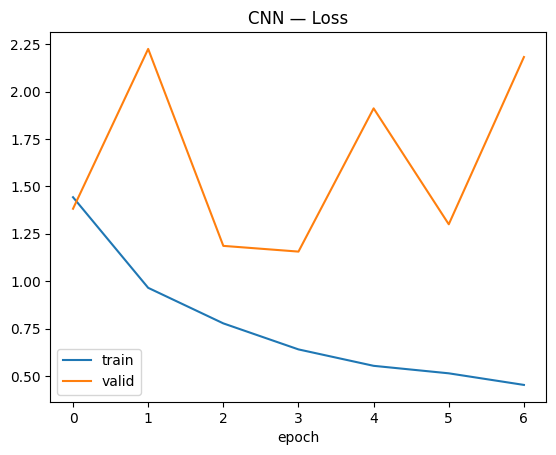

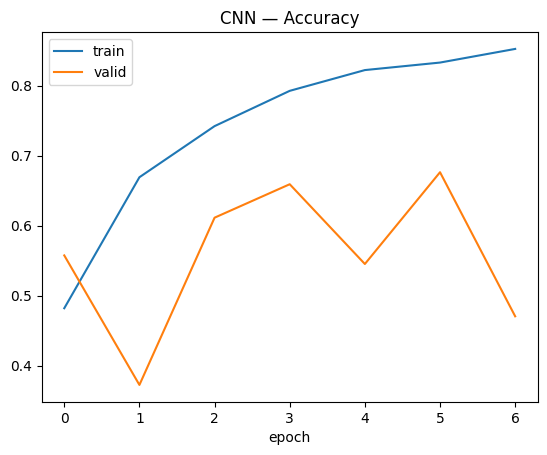

In [15]:
# TODO(1.2): Графики обучения CNN (loss/acc по эпохам)
#  Логгируйте значения из вашего цикла обучения.

import matplotlib.pyplot as plt

# Пример построения (раскомментируйте и подставьте):
plt.figure(); plt.plot(cnn_history["tr_loss"]); plt.plot(cnn_history["va_loss"]);
plt.title("CNN — Loss"); plt.legend(["train","valid"]); plt.xlabel("epoch"); plt.show()
plt.figure(); plt.plot(cnn_history["tr_acc"]); plt.plot(cnn_history["va_acc"]);
plt.title("CNN — Accuracy"); plt.legend(["train","valid"]); plt.xlabel("epoch"); plt.show()


## Задание 2. Эксперимент (выберите один вариант)

**Вариант A:** добавить SpecAugment в обучение CNN.  
**Вариант B:** изменить параметры мел-спектрограмм (например, `N_MELS`, `HOP`, `N_FFT`) и переобучить CNN.

Оформите гипотезу → что меняете → метрики ДО/ПОСЛЕ → краткий вывод.


In [25]:
# TODO(2.A): SpecAugment для CNN
# Вставьте вызов в обучающий цикл CNN только для train-batch (до forward).
# Подпишите конфигурацию масок.

import numpy as np
import torch

# Макс длина временной маски (в кадрах)
# Макс длина частотной маски (в мел-банках)
# Количество временных масок на спектрограмму
# Количество частотных масок на спектрограмму
def specaugment(x, time_mask=20, freq_mask=8, n_time_masks=1, n_freq_masks=1):
    """
    x: (B, 1, n_mels, T) — мел-спектры
    Возвращает аугментированный тензор.
    """
    # TODO: реализовать маскирование по времени и по частоте (n_time_masks / n_freq_masks)
    # Подсказка: зануляйте x[:, :, f0:f0+f, :] и x[:, :, :, t0:t0+t]
    batch_size, channels, n_mels, time_steps = x.shape
    x_aug = x.clone()

    # for _ in range(n_freq_masks):
    #     # для всего батча
    #     f_lengths = torch.randint(1, freq_mask + 1, (batch_size,))
    #     f_starts = torch.randint(0, n_mels, (batch_size,))

    #     for i in range(batch_size):
    #         f_len = min(f_lengths[i], n_mels - f_starts[i])
    #         if f_len > 0:
    #             x_aug[i, :, f_starts[i]:f_starts[i]+f_len, :] = 0

    # for _ in range(n_time_masks):
    #     t_lengths = torch.randint(1, time_mask + 1, (batch_size,))
    #     t_starts = torch.randint(0, time_steps, (batch_size,))

    #     for i in range(batch_size):
    #         t_len = min(t_lengths[i], time_steps - t_starts[i])
    #         if t_len > 0:
    #             x_aug[i, :, :, t_starts[i]:t_starts[i]+t_len] = 0



    for _ in range(n_freq_masks):
        for i in range(batch_size):
            f = torch.randint(1, min(freq_mask, n_mels-1) + 1, (1,)).item()  # ← ограничение
            f0 = torch.randint(0, max(1, n_mels - f), (1,)).item()
            x_aug[i, :, f0:f0+f, :] = 0

    # Маскирование по времени - ОГРАНИЧИТЬ максимальную длину!
    for _ in range(n_time_masks):
        for i in range(batch_size):
            t = torch.randint(1, min(time_mask, time_steps-1) + 1, (1,)).item()  # ← ограничение
            t0 = torch.randint(0, max(1, time_steps - t), (1,)).item()
            x_aug[i, :, :, t0:t0+t] = 0

    return x_aug

# Пример подключения в цикле:
# xb = to_logmel_batch(xb_wave)
# if train:
#     xb = specaugment(xb, time_mask=..., freq_mask=...)
# logits = model(xb)


In [26]:
model2 = None
model2 = VGGishAudio(len(label2id)).to(device)

def run_epoch2(loader, train=True, tag=""):
    model2.train() if train else model2.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for xb_wave, yb in tqdm(loader, desc=tag, leave=False):
        xb_wave, yb = xb_wave.to(device), yb.to(device)
        xb = to_logmel_batch(xb_wave)

        if train:
          xb = specaugment(xb,
                          time_mask=4,       # ~62 мс (вместо 234 мс)
                          freq_mask=2,       # ~3% частот (вместо 9%)
                          n_time_masks=1,    # только 1 маска времени
                          n_freq_masks=1     # только 1 маска частот
                      )

        if train: opt.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            logits = model2(xb); loss = crit(logits, yb)
            if train: loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0)
        pred = logits.argmax(1); correct += (pred==yb).sum().item(); total += xb.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

    accuracy = correct/total
    f1 = f1_score(all_targets, all_preds, average='macro')
    return loss_sum/total, accuracy, f1

In [27]:
epochs = 8
cnn_history_2 = {
    "tr_loss": [], "tr_acc": [], "tr_f1": [],
    "va_loss": [], "va_acc": [], "va_f1": []
}

for ep in range(1, epochs):
    tr_l, tr_a, tr_f1 = run_epoch2(train_loader, True,  f"train {ep}/{epochs}")
    va_l, va_a, va_f1 = run_epoch2(val_loader,   False, f"valid {ep}/{epochs}")
    cnn_history_2["tr_loss"].append(tr_l)
    cnn_history_2["tr_acc"].append(tr_a)
    cnn_history_2["tr_f1"].append(tr_f1)
    cnn_history_2["va_loss"].append(va_l)
    cnn_history_2["va_acc"].append(va_a)
    cnn_history_2["va_f1"].append(va_f1)
    print(f"Ep {ep:02d}: train {tr_l:.4f}/{tr_a:.3f} | valid {va_l:.4f}/{va_a:.3f}")

# Тест
model2.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for xb_wave, yb in tqdm(test_loader, desc="test", leave=False):
        logits = model2(to_logmel_batch(xb_wave.to(device)))
        y_true += yb.numpy().tolist()
        y_pred += logits.argmax(1).cpu().numpy().tolist()
print("CNN-aug TEST acc:", accuracy_score(y_true, y_pred))
print("CNN-aug TEST f1:", f1_score(y_true, y_pred, average='macro'))

Ep 01: train 2.3109/0.107 | valid 2.2974/0.150


Ep 02: train 2.3091/0.107 | valid 2.2970/0.148


Ep 03: train 2.3122/0.105 | valid 2.2977/0.150


Ep 04: train 2.3122/0.096 | valid 2.2979/0.153


Ep 05: train 2.3124/0.103 | valid 2.2975/0.154


Ep 06: train 2.3119/0.108 | valid 2.2975/0.153


Ep 07: train 2.3105/0.102 | valid 2.2976/0.142


CNN-aug TEST acc: 0.11827956989247312
CNN-aug TEST f1: 0.03053162582704797


In [28]:
# нужное
print(cnn_history_2['va_acc'][-1])
print(cnn_history_2['va_f1'][-1])

0.14215686274509803
0.0493185423777703


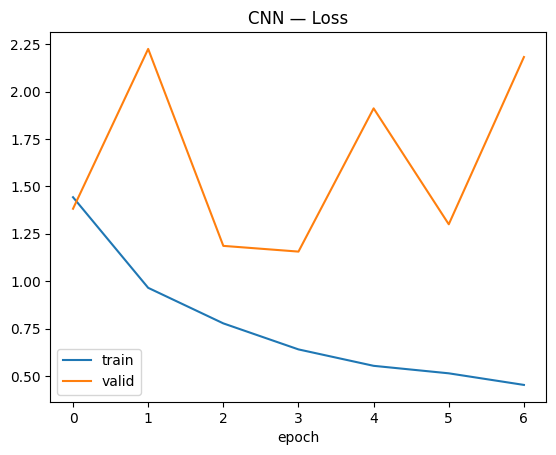

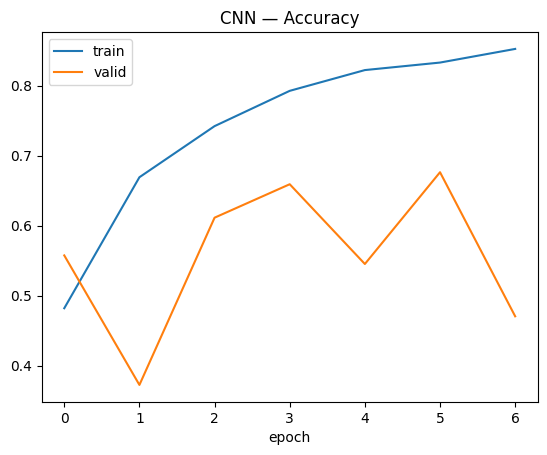

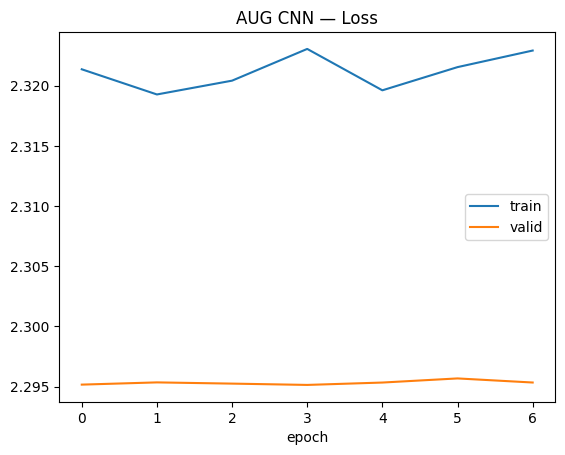

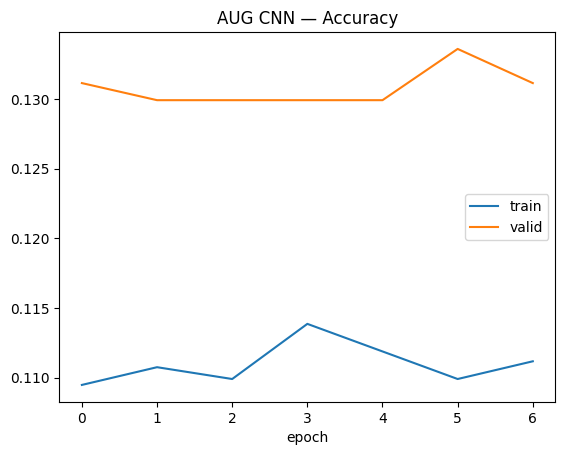

In [16]:
plt.figure(); plt.plot(cnn_history["tr_loss"]); plt.plot(cnn_history["va_loss"]);
plt.title("CNN — Loss"); plt.legend(["train","valid"]); plt.xlabel("epoch"); plt.show()
plt.figure(); plt.plot(cnn_history["tr_acc"]); plt.plot(cnn_history["va_acc"]);
plt.title("CNN — Accuracy"); plt.legend(["train","valid"]); plt.xlabel("epoch"); plt.show()

plt.figure(); plt.plot(cnn_history_2["tr_loss"]); plt.plot(cnn_history_2["va_loss"]);
plt.title("AUG CNN — Loss"); plt.legend(["train","valid"]); plt.xlabel("epoch"); plt.show()
plt.figure(); plt.plot(cnn_history_2["tr_acc"]); plt.plot(cnn_history_2["va_acc"]);
plt.title("AUG CNN — Accuracy"); plt.legend(["train","valid"]); plt.xlabel("epoch"); plt.show()

In [ ]:
# TODO(2.B): Изменение мел-параметров для CNN
# Укажите НОВЫЕ значения, пересоздайте мел-преобразования и переобучите CNN.

# Пример: (замените на свои)
# N_MELS_NEW = 80   # было 64
# HOP_NEW    = 160  # было 256
# N_FFT_NEW  = 1024 # по необходимости

# 1) Пересоздайте MelSpectrogram/AmplitudeToDB с новыми параметрами
# 2) Обновите функцию to_logmel_batch (если параметры зашиты)
# 3) Переобучите CNN и посчитаете метрики (VAL/TEST)


## Задание 3. Инференс AST на собственных `.wav`
Загрузите файл(ы), при необходимости ресемплируйте до 16kHz, сделайте топ-K предсказаний AST и прокомментируйте результаты.


In [37]:
# TODO(3): Инференс AST на своём .wav
# Требуются: processor, ast (обученная модель), SR, id2label

import soundfile as sf

def ast_predict_wav(path, top_k=3):
    # 1) загрузка .wav
    wav, sr = sf.read(path)
    wav = wav.astype(np.float32)

    if len(wav) < 400:
        repeats = (400 // len(wav)) + 1
        wav = np.tile(wav, repeats)

    #(RMS normalization)
    rms = np.sqrt(np.mean(wav**2))
    if rms > 0:
        wav = wav * (0.1 / rms)

    if len(wav.shape) > 1:
        wav = np.mean(wav, axis=1)

    # 3) препроцессинг
    inputs = processor(wav, sampling_rate=SR, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(ast.device) for k, v in inputs.items()}

    # 4) инференс
    ast.eval()
    with torch.no_grad():
        logits = ast(**inputs).logits
        probs = torch.softmax(logits, dim=-1).squeeze(0)

    # 5) топ-K
    vals, idx = torch.topk(probs, k=min(top_k, probs.numel()))
    vals, idx = vals.cpu().numpy(), idx.cpu().numpy()
    return [(id2label[int(i)], float(v)) for i, v in zip(idx, vals)]

# Пример:
ast_predict_wav("talking.wav", top_k=5)

[('street_music', 0.48301130533218384),
 ('dog_bark', 0.30822229385375977),
 ('children_playing', 0.13179029524326324),
 ('drilling', 0.03935864940285683),
 ('engine_idling', 0.02219710685312748)]

In [32]:
ast_predict_wav("enchanting-sweet-voiced-paradisiacal-birdsong.wav", top_k=5)

[('dog_bark', 0.5623078942298889),
 ('children_playing', 0.4362185299396515),
 ('street_music', 0.0006228993297554553),
 ('air_conditioner', 0.0001862536446424201),
 ('gun_shot', 0.00014936699881218374)]

In [33]:
ast_predict_wav("engine-start-and-sound.wav", top_k=5)

[('drilling', 0.7383299469947815),
 ('engine_idling', 0.21402858197689056),
 ('siren', 0.031136328354477882),
 ('air_conditioner', 0.01243364904075861),
 ('street_music', 0.0027953987009823322)]

In [34]:
ast_predict_wav("knocking.wav", top_k=5)

[('air_conditioner', 0.6878459453582764),
 ('gun_shot', 0.2867368459701538),
 ('dog_bark', 0.012330558151006699),
 ('drilling', 0.0037505216896533966),
 ('children_playing', 0.0029705308843404055)]

In [35]:
ast_predict_wav("sax-sound.wav", top_k=5)

[('drilling', 0.9235035181045532),
 ('jackhammer', 0.0680847093462944),
 ('engine_idling', 0.004490673542022705),
 ('street_music', 0.0015084162587299943),
 ('dog_bark', 0.001281270757317543)]

In [36]:
ast_predict_wav("medoed-talks.wav", top_k=5)

[('street_music', 0.9988552331924438),
 ('dog_bark', 0.0005556977703236043),
 ('children_playing', 0.00022750177595298737),
 ('drilling', 0.00015995030116755515),
 ('engine_idling', 9.21999744605273e-05)]